<a href="https://colab.research.google.com/github/2005monicagarcia-arch/PortfolioOptimizationURE26/blob/Thao/02_DS1_ML_RF%2BSNN%2BLR__Walk_forward_validation_Threshold_sensitivity_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()

Saving portfolio_option1_EFA_VNQ_20years.csv to portfolio_option1_EFA_VNQ_20years.csv


In [6]:
# ============================================================
# STAGE 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Stage 1 completed successfully.")

Stage 1 completed successfully.


In [7]:
# ============================================================
# STAGE 2: CHECK AVAILABLE DATA OBJECTS
# ============================================================

possible_variables = [
    "df",
    "data",
    "adj_close",
    "monthly_prices",
    "monthly_returns",
    "ml_data",
    "features"
]

for variable_name in possible_variables:
    print(
        variable_name,
        "exists:",
        variable_name in globals()
    )

print("\nAvailable DataFrames:")
%whos DataFrame

df exists: False
data exists: False
adj_close exists: False
monthly_prices exists: False
monthly_returns exists: False
ml_data exists: False
features exists: False

Available DataFrames:
No variables match your requested type.


In [8]:
# ============================================================
# STAGE 3A: UPLOAD DATA FILE
# ============================================================

from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print("-", filename)

Saving portfolio_option1_EFA_VNQ_20years.csv to portfolio_option1_EFA_VNQ_20years (1).csv
Uploaded files:
- portfolio_option1_EFA_VNQ_20years (1).csv


In [9]:
# ============================================================
# STAGE 3B: READ RAW CSV FILE
# ============================================================

import pandas as pd

FILE_NAME = list(uploaded.keys())[0]

raw_data = pd.read_csv(
    FILE_NAME,
    header=[0, 1],
    index_col=0,
    parse_dates=True
)

print("File loaded successfully.")
print("Shape:", raw_data.shape)
print("Date range:", raw_data.index.min(), "to", raw_data.index.max())

display(raw_data.head())

File loaded successfully.
Shape: (5153, 54)
Date range: 2006-01-03 00:00:00 to 2026-06-29 00:00:00


Price      Adj Close                                                        \
Ticker          AAPL        EFA        IEF       MSFT      NVDA        QQQ   
Date                                                                         
2006-01-03  2.237673  33.620350  49.090813  18.632084  0.291656  35.273769   
2006-01-04  2.244259  33.899529  49.178551  18.722328  0.299822  35.640934   
2006-01-05  2.226598  33.729832  49.190231  18.736214  0.306612  35.794636   
2006-01-06  2.284073  34.184166  49.125893  18.680685  0.311649  36.443584   
2006-01-09  2.276588  34.200577  49.149277  18.645973  0.320348  36.588745   

Price                                           Close  ...       Open  \
Ticker            SPY        TLT        VNQ      AAPL  ...        VNQ   
Date                                                   ...              
2006-01-03  87.000908  47.859772  25.824440  2.669643  ...  59.939999   
2006-01-04  87.412918  47.974487  26.015696  2.677500  ...  61.209999   
2006-01-05  87.467857  47.917107  26.215464  2.656429  ...  61.240002   
2006-01-06  88.195740  47.828461  26.461979  2.725000  ...  62.009998   
2006-01-09  88.422348  47.859772  26.687244  2.716071  ...  62.599998   

Price          Volume                                                    \
Ticker           AAPL      EFA     IEF       MSFT       NVDA        QQQ   
Date                                                                      
2006-01-03  807234400  7778500  299500   79973000  472812000  109350400   
2006-01-04  619603600  5231500  112300   57975600  510072000   92769400   
2006-01-05  449422400  4953800  159700   48245500  646092000   77656900   
2006-01-06  704457600  5326600  179100  100963000  623388000  110053900   
2006-01-09  675040800  3057200   78600   55625000  560484000   80768800   

Price                                 
Ticker           SPY      TLT    VNQ  
Date                                  
2006-01-03  73256700  1392700  70300  
2006-01-04  51899600   387600  75000  
2006-01-05  47307500   453400  31200  
2006-01-06  62885900  1193700  36000  
2006-01-09  43527400   413600  49200  

[5 rows x 54 columns]

In [10]:
# ============================================================
# STAGE 4: EXTRACT PRICES AND CREATE MONTHLY RETURNS
# ============================================================

# Check available first-level columns
print("Top-level columns:")
print(raw_data.columns.get_level_values(0).unique().tolist())

# Use Adjusted Close if available; otherwise use Close
if "Adj Close" in raw_data.columns.get_level_values(0):
    adjusted_close = raw_data["Adj Close"].copy()
elif "Close" in raw_data.columns.get_level_values(0):
    adjusted_close = raw_data["Close"].copy()
else:
    raise ValueError(
        "Could not find 'Adj Close' or 'Close' in the dataset."
    )

# Clean column names
adjusted_close.columns.name = None
adjusted_close = adjusted_close.sort_index()

# Convert daily prices to month-end prices
monthly_prices = adjusted_close.resample("ME").last()

# Calculate monthly returns
monthly_returns = monthly_prices.pct_change()

# Remove rows where all assets are missing
monthly_prices = monthly_prices.dropna(how="all")
monthly_returns = monthly_returns.dropna(how="all")

print("\nStage 4 completed successfully.")
print("Assets:", monthly_prices.columns.tolist())
print("Monthly price shape:", monthly_prices.shape)
print("Monthly return shape:", monthly_returns.shape)
print(
    "Monthly date range:",
    monthly_returns.index.min(),
    "to",
    monthly_returns.index.max()
)

display(monthly_prices.head())
display(monthly_returns.head())

Top-level columns:
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Stage 4 completed successfully.
Assets: ['AAPL', 'EFA', 'IEF', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TLT', 'VNQ']
Monthly price shape: (246, 9)
Monthly return shape: (245, 9)
Monthly date range: 2006-02-28 00:00:00 to 2026-06-30 00:00:00


,AAPL,EFA,IEF,MSFT,NVDA,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,
2006-01-31,2.260425,34.408585,48.751446,19.541477,0.343089,35.862942,87.550270,47.280918,27.222775
2006-02-28,2.050277,34.167732,48.700985,18.716116,0.359648,35.094440,88.051537,47.804810,27.728548
2006-03-31,1.877549,35.536201,48.039654,18.952944,0.436950,35.828281,89.504730,45.620144,29.035961
2006-04-30,2.107155,37.238564,47.738392,16.821518,0.445954,35.759937,90.635361,44.364506,28.048433
2006-05-31,1.789241,35.815361,47.687382,15.838223,0.350720,33.170868,87.905327,44.279793,27.291752


,AAPL,EFA,IEF,MSFT,NVDA,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,
2006-02-28,-0.092969,-0.007000,-0.001035,-0.042236,0.048264,-0.021429,0.005725,0.011080,0.018579
2006-03-31,-0.084246,0.040052,-0.013579,0.012654,0.214938,0.020910,0.016504,-0.045700,0.047150
2006-04-30,0.122290,0.047905,-0.006271,-0.112459,0.020607,-0.001908,0.012632,-0.027524,-0.034011
2006-05-31,-0.150873,-0.038219,-0.001069,-0.058455,-0.213553,-0.072401,-0.030121,-0.001909,-0.026978
2006-06-30,-0.041828,-0.000611,0.002297,0.028698,-0.073543,-0.000616,0.002608,0.011783,0.049610


In [14]:
# ============================================================
# STAGE 5: CREATE MACHINE LEARNING DATASET
# ============================================================

feature_data = []

for ticker in monthly_returns.columns:

    temp = pd.DataFrame(
        index=monthly_returns.index
    )

    temp["ticker"] = ticker

    # --------------------------------------------------------
    # LAGGED RETURN FEATURES
    # --------------------------------------------------------

    temp["return_1m"] = (
        monthly_returns[ticker]
        .shift(1)
    )

    temp["return_3m"] = (
        monthly_returns[ticker]
        .rolling(3)
        .sum()
        .shift(1)
    )

    temp["return_6m"] = (
        monthly_returns[ticker]
        .rolling(6)
        .sum()
        .shift(1)
    )

    # --------------------------------------------------------
    # LAGGED VOLATILITY FEATURES
    # --------------------------------------------------------

    temp["volatility_3m"] = (
        monthly_returns[ticker]
        .rolling(3)
        .std()
        .shift(1)
    )

    temp["volatility_6m"] = (
        monthly_returns[ticker]
        .rolling(6)
        .std()
        .shift(1)
    )

    # --------------------------------------------------------
    # LAGGED TREND FEATURE
    # --------------------------------------------------------

    moving_average_3m = (
        monthly_prices[ticker]
        .rolling(3)
        .mean()
    )

    temp["trend_signal"] = (
        monthly_prices[ticker].shift(1)
        >
        moving_average_3m.shift(1)
    ).astype(int)

    # --------------------------------------------------------
    # TARGET AND REALIZED RETURN
    # --------------------------------------------------------

    temp["actual_return"] = (
        monthly_returns[ticker]
    )

    temp["target"] = (
        temp["actual_return"] > 0
    ).astype(int)

    feature_data.append(temp)


ml_data = pd.concat(
    feature_data
).sort_index()

features = [
    "return_1m",
    "return_3m",
    "return_6m",
    "volatility_3m",
    "volatility_6m",
    "trend_signal"
]

required_columns = (
    ["ticker"]
    + features
    + [
        "actual_return",
        "target"
    ]
)

ml_data = (
    ml_data[required_columns]
    .dropna()
    .sort_index()
)

print("Stage 5 completed successfully.")
print("ML dataset shape:", ml_data.shape)
print(
    "Date range:",
    ml_data.index.min(),
    "to",
    ml_data.index.max()
)
print(
    "Assets:",
    ml_data["ticker"].unique().tolist()
)
print(
    "Features:",
    features
)

print("\nTarget distribution:")

display(
    ml_data["target"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Negative/Zero Return",
        1: "Positive Return"
    })
    .to_frame("Count")
)

display(
    ml_data.head(10)
)

Stage 5 completed successfully.
ML dataset shape: (2151, 9)
Date range: 2006-08-31 00:00:00 to 2026-06-30 00:00:00
Assets: ['TLT', 'IEF', 'QQQ', 'MSFT', 'EFA', 'AAPL', 'VNQ', 'NVDA', 'SPY']
Features: ['return_1m', 'return_3m', 'return_6m', 'volatility_3m', 'volatility_6m', 'trend_signal']

Target distribution:


,Count
target,
Negative/Zero Return,864
Positive Return,1287


,ticker,return_1m,return_3m,return_6m,volatility_3m,volatility_6m,trend_signal,actual_return,target
Date,,,,,,,,,
2006-08-31,TLT,0.021633,0.031506,-0.030637,0.011823,0.026164,1,0.030562,1
2006-08-31,IEF,0.016772,0.018001,-0.002885,0.009479,0.010111,1,0.017636,1
2006-08-31,QQQ,-0.043075,-0.116092,-0.118518,0.036093,0.033636,0,0.047710,1
2006-08-31,MSFT,0.032618,0.002861,-0.139180,0.051487,0.057736,1,0.072096,1
2006-08-31,EFA,0.008106,-0.030724,0.050232,0.024618,0.031794,1,0.025485,1
2006-08-31,AAPL,0.186660,-0.006041,-0.060966,0.172253,0.133739,1,-0.001619,0
2006-08-31,VNQ,0.038914,0.061547,0.093266,0.041477,0.037359,1,0.034843,1
2006-08-31,NVDA,0.039926,-0.247169,0.036640,0.126971,0.142363,1,0.314815,1
2006-08-31,SPY,0.004478,-0.023035,0.011827,0.019459,0.016586,1,0.021822,1


In [15]:
# ============================================================
# STAGE 6: HELPER FUNCTIONS
# ============================================================

def build_model_portfolio(
    prediction_data,
    prediction_column
):
    """
    Build an equal-weight portfolio from assets predicted as positive.
    If no asset is selected in a month, portfolio return is set to 0.
    """

    portfolio_rows = []

    for date, month_data in prediction_data.groupby(
        prediction_data.index
    ):

        selected_assets = month_data[
            month_data[prediction_column] == 1
        ]

        if len(selected_assets) > 0:

            portfolio_return = selected_assets[
                "actual_return"
            ].mean()

            selected_tickers = selected_assets[
                "ticker"
            ].tolist()

        else:

            portfolio_return = 0.0
            selected_tickers = []

        portfolio_rows.append({
            "Date": date,
            "Portfolio_Return": portfolio_return,
            "Selected_Assets": selected_tickers,
            "Number_of_Assets": len(selected_tickers)
        })

    portfolio_df = pd.DataFrame(
        portfolio_rows
    )

    portfolio_df["Date"] = pd.to_datetime(
        portfolio_df["Date"]
    )

    portfolio_df = (
        portfolio_df
        .sort_values("Date")
        .set_index("Date")
    )

    return portfolio_df


def calculate_portfolio_metrics(
    returns,
    periods_per_year=12
):
    """
    Calculate portfolio performance metrics from monthly returns.
    """

    returns = returns.dropna()

    if len(returns) == 0:
        return {
            "Total Return": np.nan,
            "CAGR": np.nan,
            "Annual Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Maximum Drawdown": np.nan
        }

    cumulative_growth = (
        1 + returns
    ).cumprod()

    total_return = (
        cumulative_growth.iloc[-1] - 1
    )

    years = len(returns) / periods_per_year

    cagr = (
        cumulative_growth.iloc[-1] ** (1 / years)
        - 1
    )

    annual_volatility = (
        returns.std()
        * np.sqrt(periods_per_year)
    )

    annual_return = (
        returns.mean()
        * periods_per_year
    )

    sharpe_ratio = (
        annual_return / annual_volatility
        if annual_volatility > 0
        else np.nan
    )

    running_peak = cumulative_growth.cummax()

    drawdown = (
        cumulative_growth / running_peak
        - 1
    )

    maximum_drawdown = drawdown.min()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown
    }


print("Stage 6 completed successfully.")
print("Helper functions are ready.")

Stage 6 completed successfully.
Helper functions are ready.


In [18]:
# ============================================================
# FIX: DEFINE RANDOM STATE
# ============================================================

RANDOM_STATE = 42

print("RANDOM_STATE =", RANDOM_STATE)

RANDOM_STATE = 42


In [19]:
# ============================================================
# STAGE 7: WALK-FORWARD VALIDATION
# Logistic Regression + Random Forest + SNN
# ============================================================

walk_forward_results_list = []

all_dates = sorted(
    ml_data.index.unique()
)

MIN_TRAIN_MONTHS = 60

print("Total available months:", len(all_dates))
print("Initial training months:", MIN_TRAIN_MONTHS)
print(
    "Walk-forward test months:",
    len(all_dates) - MIN_TRAIN_MONTHS
)

for i in range(
    MIN_TRAIN_MONTHS,
    len(all_dates)
):

    train_dates = all_dates[:i]
    test_date = all_dates[i]

    train_data = ml_data[
        ml_data.index.isin(train_dates)
    ].copy()

    test_data = ml_data[
        ml_data.index == test_date
    ].copy()

    if test_data.empty:
        continue

    X_train = train_data[features]
    y_train = train_data["target"].astype(int)

    X_test = test_data[features]

    # --------------------------------------------------------
    # 1. LOGISTIC REGRESSION
    # --------------------------------------------------------

    logistic_model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ])

    logistic_model.fit(
        X_train,
        y_train
    )

    logistic_probability = (
        logistic_model
        .predict_proba(X_test)[:, 1]
    )

    # --------------------------------------------------------
    # 2. RANDOM FOREST
    # --------------------------------------------------------

    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rf_model.fit(
        X_train,
        y_train
    )

    rf_probability = (
        rf_model
        .predict_proba(X_test)[:, 1]
    )

    # --------------------------------------------------------
    # 3. SIMPLE NEURAL NETWORK
    # --------------------------------------------------------

    snn_model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(16, 8),
                activation="relu",
                solver="adam",
                alpha=0.001,
                learning_rate_init=0.001,
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                random_state=RANDOM_STATE
            )
        )
    ])

    snn_model.fit(
        X_train,
        y_train
    )

    snn_probability = (
        snn_model
        .predict_proba(X_test)[:, 1]
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    month_results = test_data[
        [
            "ticker",
            "actual_return",
            "target"
        ]
    ].copy()

    month_results["test_date"] = test_date

    month_results[
        "logistic_probability"
    ] = logistic_probability

    month_results[
        "rf_probability"
    ] = rf_probability

    month_results[
        "snn_probability"
    ] = snn_probability

    walk_forward_results_list.append(
        month_results
    )

    completed_months = (
        i - MIN_TRAIN_MONTHS + 1
    )

    if completed_months % 12 == 0:
        print(
            f"Completed {completed_months} test months "
            f"through {pd.Timestamp(test_date).strftime('%Y-%m')}"
        )


walk_forward_results = pd.concat(
    walk_forward_results_list
).sort_index()

print("\nStage 7 completed successfully.")
print(
    "Walk-forward results shape:",
    walk_forward_results.shape
)
print(
    "Test date range:",
    walk_forward_results.index.min(),
    "to",
    walk_forward_results.index.max()
)

print("\nColumns:")
print(
    walk_forward_results.columns.tolist()
)

display(
    walk_forward_results.head(10)
)

Total available months: 239
Initial training months: 60
Walk-forward test months: 179
Completed 12 test months through 2012-07
Completed 24 test months through 2013-07
Completed 36 test months through 2014-07
Completed 48 test months through 2015-07
Completed 60 test months through 2016-07
Completed 72 test months through 2017-07
Completed 84 test months through 2018-07
Completed 96 test months through 2019-07
Completed 108 test months through 2020-07
Completed 120 test months through 2021-07
Completed 132 test months through 2022-07
Completed 144 test months through 2023-07
Completed 156 test months through 2024-07
Completed 168 test months through 2025-07

Stage 7 completed successfully.
Walk-forward results shape: (1611, 7)
Test date range: 2011-08-31 00:00:00 to 2026-06-30 00:00:00

Columns:
['ticker', 'actual_return', 'target', 'test_date', 'logistic_probability', 'rf_probability', 'snn_probability']


,ticker,actual_return,target,test_date,logistic_probability,rf_probability,snn_probability
Date,,,,,,,
2011-08-31,AAPL,-0.014469,0,2011-08-31,0.652576,0.726263,0.582535
2011-08-31,EFA,-0.087549,0,2011-08-31,0.566267,0.536188,0.646408
2011-08-31,VNQ,-0.056193,0,2011-08-31,0.582388,0.535026,0.674731
2011-08-31,QQQ,-0.050689,0,2011-08-31,0.589461,0.624157,0.598813
2011-08-31,NVDA,-0.037600,0,2011-08-31,0.485771,0.355063,0.363280
2011-08-31,SPY,-0.054976,0,2011-08-31,0.571582,0.576082,0.654457
2011-08-31,MSFT,-0.023070,0,2011-08-31,0.634838,0.642700,0.596589
2011-08-31,TLT,0.096674,1,2011-08-31,0.611516,0.660179,0.604670
2011-08-31,IEF,0.046514,1,2011-08-31,0.615982,0.653310,0.591060


In [20]:
# ============================================================
# STAGE 8: THRESHOLD SENSITIVITY ANALYSIS
# Logistic Regression + Random Forest + SNN
# ============================================================

thresholds = [
    0.50,
    0.55,
    0.60,
    0.65
]

model_probability_columns = {
    "Logistic Regression": "logistic_probability",
    "Random Forest": "rf_probability",
    "Simple Neural Network": "snn_probability"
}

threshold_results = []

y_true = walk_forward_results[
    "target"
].astype(int)

for model_name, probability_column in model_probability_columns.items():

    probabilities = walk_forward_results[
        probability_column
    ]

    for threshold in thresholds:

        prediction_column = (
            f"{probability_column}_threshold_{threshold:.2f}"
        )

        # Convert probability into prediction
        walk_forward_results[
            prediction_column
        ] = (
            probabilities >= threshold
        ).astype(int)

        y_pred = walk_forward_results[
            prediction_column
        ].astype(int)

        # Confusion matrix values
        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        # Create portfolio for this model and threshold
        threshold_portfolio = build_model_portfolio(
            walk_forward_results,
            prediction_column
        )

        threshold_returns = threshold_portfolio[
            "Portfolio_Return"
        ]

        portfolio_metrics = calculate_portfolio_metrics(
            threshold_returns
        )

        threshold_results.append({
            "Model": model_name,
            "Threshold": threshold,

            "Accuracy":
                accuracy_score(
                    y_true,
                    y_pred
                ),

            "Balanced Accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred
                ),

            "Positive Precision":
                precision_score(
                    y_true,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                ),

            "Positive Recall":
                recall_score(
                    y_true,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                ),

            "Negative Recall":
                recall_score(
                    y_true,
                    y_pred,
                    pos_label=0,
                    zero_division=0
                ),

            "Positive F1":
                f1_score(
                    y_true,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                ),

            "Actual Positive Rate":
                y_true.mean(),

            "Predicted Positive Rate":
                y_pred.mean(),

            "Average Assets Selected":
                threshold_portfolio[
                    "Number_of_Assets"
                ].mean(),

            "Total Return":
                portfolio_metrics[
                    "Total Return"
                ],

            "CAGR":
                portfolio_metrics[
                    "CAGR"
                ],

            "Annual Volatility":
                portfolio_metrics[
                    "Annual Volatility"
                ],

            "Sharpe Ratio":
                portfolio_metrics[
                    "Sharpe Ratio"
                ],

            "Maximum Drawdown":
                portfolio_metrics[
                    "Maximum Drawdown"
                ],

            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })


threshold_comparison = pd.DataFrame(
    threshold_results
)

print("Stage 8 completed successfully.")
print(
    "Number of threshold tests:",
    len(threshold_comparison)
)

display(
    threshold_comparison.style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.2%}",
        "Balanced Accuracy": "{:.2%}",
        "Positive Precision": "{:.2%}",
        "Positive Recall": "{:.2%}",
        "Negative Recall": "{:.2%}",
        "Positive F1": "{:.2%}",
        "Actual Positive Rate": "{:.2%}",
        "Predicted Positive Rate": "{:.2%}",
        "Average Assets Selected": "{:.2f}",
        "Total Return": "{:.2%}",
        "CAGR": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}"
    })
)

Stage 8 completed successfully.
Number of threshold tests: 12


,Model,Threshold,Accuracy,Balanced Accuracy,Positive Precision,Positive Recall,Negative Recall,Positive F1,Actual Positive Rate,Predicted Positive Rate,Average Assets Selected,Total Return,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown,TN,FP,FN,TP
0,Logistic Regression,0.50,59.71%,49.72%,60.14%,98.35%,1.09%,74.64%,60.27%,98.57%,8.87,1013.63%,17.54%,13.72%,1.253,-31.02%,7,633,16,955
1,Logistic Regression,0.55,57.36%,48.49%,59.49%,91.66%,5.31%,72.15%,60.27%,92.86%,8.36,744.15%,15.37%,13.27%,1.150,-31.03%,34,606,81,890
2,Logistic Regression,0.60,47.36%,49.14%,59.28%,40.47%,57.81%,48.10%,60.27%,41.15%,3.70,751.61%,15.44%,16.50%,0.956,-49.29%,370,270,578,393
3,Logistic Regression,0.65,41.90%,51.08%,69.66%,6.39%,95.78%,11.70%,60.27%,5.52%,0.50,209.96%,7.88%,16.91%,0.532,-24.79%,613,27,909,62
4,Random Forest,0.50,58.41%,48.85%,59.70%,95.37%,2.34%,73.43%,60.27%,96.28%,8.66,886.35%,16.58%,13.37%,1.222,-30.36%,15,625,45,926
5,Random Forest,0.55,55.12%,48.47%,59.38%,80.84%,16.09%,68.47%,60.27%,82.06%,7.39,753.27%,15.46%,13.77%,1.118,-31.18%,103,537,186,785
6,Random Forest,0.60,50.16%,50.24%,60.50%,49.85%,50.62%,54.66%,60.27%,49.66%,4.47,623.18%,14.18%,19.40%,0.782,-35.29%,324,316,487,484
7,Random Forest,0.65,43.02%,50.39%,61.57%,14.52%,86.25%,23.50%,60.27%,14.21%,1.28,493.47%,12.68%,21.32%,0.667,-44.93%,552,88,830,141
8,Simple Neural Network,0.50,59.78%,49.93%,60.24%,97.84%,2.03%,74.57%,60.27%,97.89%,8.81,935.27%,16.96%,13.62%,1.226,-31.59%,13,627,21,950
9,Simple Neural Network,0.55,59.65%,50.71%,60.64%,94.23%,7.19%,73.79%,60.27%,93.67%,8.43,910.65%,16.77%,13.27%,1.242,-27.18%,46,594,56,915


In [21]:
# ============================================================
# STAGE 9A: SUMMARIZE THRESHOLD RESULTS
# ============================================================

best_by_balanced_accuracy = (
    threshold_comparison
    .sort_values(
        ["Model", "Balanced Accuracy"],
        ascending=[True, False]
    )
    .groupby("Model", as_index=False)
    .first()
)

best_by_sharpe = (
    threshold_comparison
    .sort_values(
        ["Model", "Sharpe Ratio"],
        ascending=[True, False]
    )
    .groupby("Model", as_index=False)
    .first()
)

best_by_cagr = (
    threshold_comparison
    .sort_values(
        ["Model", "CAGR"],
        ascending=[True, False]
    )
    .groupby("Model", as_index=False)
    .first()
)


print("Best threshold by Balanced Accuracy")

display(
    best_by_balanced_accuracy[
        [
            "Model",
            "Threshold",
            "Balanced Accuracy",
            "Positive Recall",
            "Negative Recall",
            "Sharpe Ratio",
            "CAGR"
        ]
    ].style.format({
        "Threshold": "{:.2f}",
        "Balanced Accuracy": "{:.2%}",
        "Positive Recall": "{:.2%}",
        "Negative Recall": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "CAGR": "{:.2%}"
    })
)


print("\nBest threshold by Sharpe Ratio")

display(
    best_by_sharpe[
        [
            "Model",
            "Threshold",
            "Sharpe Ratio",
            "CAGR",
            "Maximum Drawdown",
            "Balanced Accuracy",
            "Average Assets Selected"
        ]
    ].style.format({
        "Threshold": "{:.2f}",
        "Sharpe Ratio": "{:.3f}",
        "CAGR": "{:.2%}",
        "Maximum Drawdown": "{:.2%}",
        "Balanced Accuracy": "{:.2%}",
        "Average Assets Selected": "{:.2f}"
    })
)


print("\nBest threshold by CAGR")

display(
    best_by_cagr[
        [
            "Model",
            "Threshold",
            "CAGR",
            "Sharpe Ratio",
            "Maximum Drawdown",
            "Balanced Accuracy",
            "Average Assets Selected"
        ]
    ].style.format({
        "Threshold": "{:.2f}",
        "CAGR": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}",
        "Balanced Accuracy": "{:.2%}",
        "Average Assets Selected": "{:.2f}"
    })
)

print("\nStage 9A completed successfully.")

Best threshold by Balanced Accuracy


,Model,Threshold,Balanced Accuracy,Positive Recall,Negative Recall,Sharpe Ratio,CAGR
0,Logistic Regression,0.65,51.08%,6.39%,95.78%,0.532,7.88%
1,Random Forest,0.65,50.39%,14.52%,86.25%,0.667,12.68%
2,Simple Neural Network,0.55,50.71%,94.23%,7.19%,1.242,16.77%



Best threshold by Sharpe Ratio


,Model,Threshold,Sharpe Ratio,CAGR,Maximum Drawdown,Balanced Accuracy,Average Assets Selected
0,Logistic Regression,0.50,1.253,17.54%,-31.02%,49.72%,8.87
1,Random Forest,0.50,1.222,16.58%,-30.36%,48.85%,8.66
2,Simple Neural Network,0.55,1.242,16.77%,-27.18%,50.71%,8.43



Best threshold by CAGR


,Model,Threshold,CAGR,Sharpe Ratio,Maximum Drawdown,Balanced Accuracy,Average Assets Selected
0,Logistic Regression,0.50,17.54%,1.253,-31.02%,49.72%,8.87
1,Random Forest,0.50,16.58%,1.222,-30.36%,48.85%,8.66
2,Simple Neural Network,0.50,16.96%,1.226,-31.59%,49.93%,8.81



Stage 9A completed successfully.



Logistic Regression
Threshold: 0.5
                 precision    recall  f1-score   support

Negative Return     0.3043    0.0109    0.0211       640
Positive Return     0.6014    0.9835    0.7464       971

       accuracy                         0.5971      1611
      macro avg     0.4529    0.4972    0.3838      1611
   weighted avg     0.4834    0.5971    0.4583      1611



,Predicted Negative,Predicted Positive
Actual Negative,7,633
Actual Positive,16,955


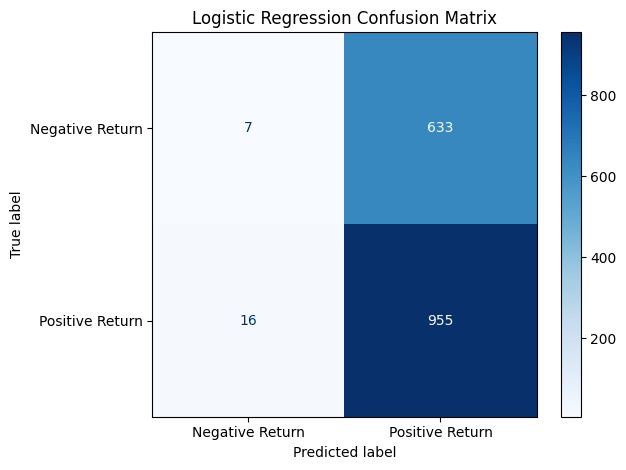


Random Forest
Threshold: 0.5
                 precision    recall  f1-score   support

Negative Return     0.2500    0.0234    0.0429       640
Positive Return     0.5970    0.9537    0.7343       971

       accuracy                         0.5841      1611
      macro avg     0.4235    0.4885    0.3886      1611
   weighted avg     0.4592    0.5841    0.4596      1611



,Predicted Negative,Predicted Positive
Actual Negative,15,625
Actual Positive,45,926


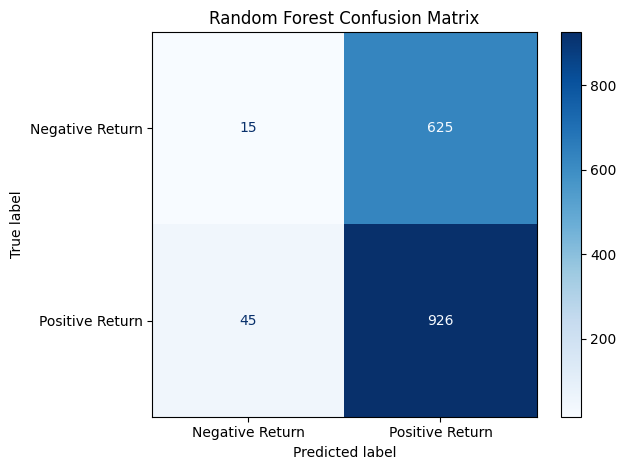


Simple Neural Network
Threshold: 0.55
                 precision    recall  f1-score   support

Negative Return     0.4510    0.0719    0.1240       640
Positive Return     0.6064    0.9423    0.7379       971

       accuracy                         0.5965      1611
      macro avg     0.5287    0.5071    0.4309      1611
   weighted avg     0.5446    0.5965    0.4940      1611



,Predicted Negative,Predicted Positive
Actual Negative,46,594
Actual Positive,56,915


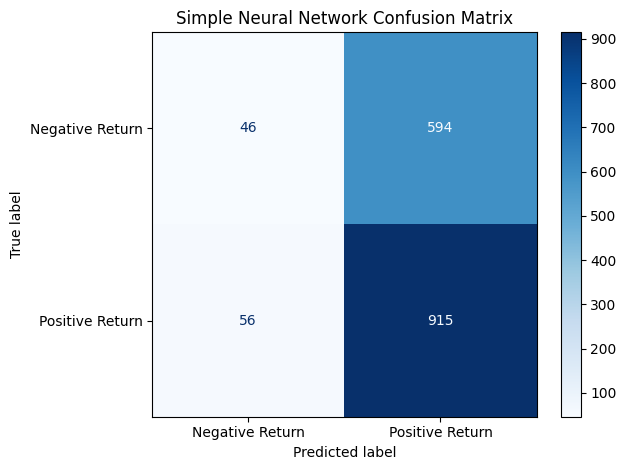


Final Classification Comparison


,Model,Threshold,Accuracy,Balanced Accuracy,Positive Precision,Positive Recall,Negative Recall,Positive F1,Actual Positive Rate,Predicted Positive Rate,TN,FP,FN,TP
0,Logistic Regression,0.50,59.71%,49.72%,60.14%,98.35%,1.09%,74.64%,60.27%,98.57%,7,633,16,955
1,Random Forest,0.50,58.41%,48.85%,59.70%,95.37%,2.34%,73.43%,60.27%,96.28%,15,625,45,926
2,Simple Neural Network,0.55,59.65%,50.71%,60.64%,94.23%,7.19%,73.79%,60.27%,93.67%,46,594,56,915



Stage 10 completed successfully.


In [25]:
# ============================================================
# STAGE 10: CLASSIFICATION REPORTS AND CONFUSION MATRICES
# ============================================================

y_true = walk_forward_results[
    "target"
].astype(int)

final_prediction_columns = {
    "Logistic Regression":
        "logistic_final_prediction",

    "Random Forest":
        "rf_final_prediction",

    "Simple Neural Network":
        "snn_final_prediction"
}

classification_rows = []

for model_name, prediction_column in final_prediction_columns.items():

    y_pred = walk_forward_results[
        prediction_column
    ].astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    classification_rows.append({
        "Model": model_name,

        "Threshold":
            FINAL_THRESHOLDS[model_name],

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Positive Precision":
            precision_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "Positive Recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "Negative Recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "Positive F1":
            f1_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "Actual Positive Rate":
            y_true.mean(),

        "Predicted Positive Rate":
            y_pred.mean(),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    print("\n" + "=" * 70)
    print(model_name)
    print(
        "Threshold:",
        FINAL_THRESHOLDS[model_name]
    )
    print("=" * 70)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Negative Return",
                "Positive Return"
            ],
            digits=4,
            zero_division=0
        )
    )

    confusion_table = pd.DataFrame(
        [
            [tn, fp],
            [fn, tp]
        ],
        index=[
            "Actual Negative",
            "Actual Positive"
        ],
        columns=[
            "Predicted Negative",
            "Predicted Positive"
        ]
    )

    display(confusion_table)

    matrix_display = ConfusionMatrixDisplay(
        confusion_matrix=np.array([
            [tn, fp],
            [fn, tp]
        ]),
        display_labels=[
            "Negative Return",
            "Positive Return"
        ]
    )

    matrix_display.plot(
        values_format="d",
        cmap="Blues"
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()


classification_comparison = pd.DataFrame(
    classification_rows
)

print("\nFinal Classification Comparison")

display(
    classification_comparison.style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.2%}",
        "Balanced Accuracy": "{:.2%}",
        "Positive Precision": "{:.2%}",
        "Positive Recall": "{:.2%}",
        "Negative Recall": "{:.2%}",
        "Positive F1": "{:.2%}",
        "Actual Positive Rate": "{:.2%}",
        "Predicted Positive Rate": "{:.2%}"
    })
)

print("\nStage 10 completed successfully.")

In [28]:
# ============================================================
# STAGE 12A: BUILD TRADITIONAL BENCHMARKS
# ============================================================

test_dates = logistic_portfolio.index

test_monthly_returns = (
    monthly_returns
    .reindex(test_dates)
    .copy()
)

# 1. Buy and Hold SPY
spy_returns = test_monthly_returns["SPY"]

# 2. Equal Weight across all available assets
equal_weight_returns = (
    test_monthly_returns.mean(axis=1)
)

# 3. 60/40 Portfolio
# 60% SPY + 20% IEF + 20% TLT
portfolio_6040_returns = (
    0.60 * test_monthly_returns["SPY"]
    + 0.20 * test_monthly_returns["IEF"]
    + 0.20 * test_monthly_returns["TLT"]
)

print("Stage 12A completed successfully.")

benchmark_preview = pd.DataFrame({
    "SPY": spy_returns,
    "Equal Weight": equal_weight_returns,
    "60/40 Portfolio": portfolio_6040_returns
})

display(
    benchmark_preview.head().style.format("{:.2%}")
)

Stage 12A completed successfully.


,SPY,Equal Weight,60/40 Portfolio
Date,,,
2011-08-31 00:00:00,-5.50%,-2.02%,-0.43%
2011-09-30 00:00:00,-6.94%,-3.44%,-1.08%
2011-10-31 00:00:00,10.91%,7.95%,5.53%
2011-11-30 00:00:00,-0.41%,-1.08%,0.27%
2011-12-31 00:00:00,1.04%,0.52%,1.71%


In [29]:
# ============================================================
# STAGE 12B: WALK-FORWARD MEAN-VARIANCE OPTIMIZATION
# ============================================================

mvo_rows = []
mvo_weight_rows = []

for test_date in test_dates:

    # Only use data available before the test month
    historical_returns = (
        monthly_returns[
            monthly_returns.index < test_date
        ]
        .dropna()
        .copy()
    )

    # Require at least 24 months of historical data
    if len(historical_returns) < 24:
        mvo_rows.append({
            "Date": test_date,
            "Portfolio_Return": np.nan
        })
        continue

    assets = historical_returns.columns

    # Annualized expected returns
    expected_returns = (
        historical_returns.mean() * 12
    )

    # Annualized covariance matrix
    covariance_matrix = (
        historical_returns.cov() * 12
    )

    # Small regularization for numerical stability
    regularized_covariance = (
        covariance_matrix.values
        + np.eye(len(assets)) * 1e-6
    )

    inverse_covariance = np.linalg.pinv(
        regularized_covariance
    )

    # Approximate maximum-Sharpe weights
    raw_weights = (
        inverse_covariance
        @ expected_returns.values
    )

    # Long-only constraint
    raw_weights = np.maximum(
        raw_weights,
        0
    )

    # Normalize weights
    if raw_weights.sum() == 0:
        weights = np.repeat(
            1 / len(assets),
            len(assets)
        )
    else:
        weights = (
            raw_weights / raw_weights.sum()
        )

    current_returns = monthly_returns.loc[
        test_date,
        assets
    ]

    mvo_return = np.dot(
        weights,
        current_returns.values
    )

    mvo_rows.append({
        "Date": test_date,
        "Portfolio_Return": mvo_return
    })

    weight_row = {
        "Date": test_date
    }

    for asset, weight in zip(
        assets,
        weights
    ):
        weight_row[asset] = weight

    mvo_weight_rows.append(
        weight_row
    )


mvo_portfolio = pd.DataFrame(
    mvo_rows
)

mvo_portfolio["Date"] = pd.to_datetime(
    mvo_portfolio["Date"]
)

mvo_portfolio = (
    mvo_portfolio
    .set_index("Date")
    .sort_index()
)

mvo_weights = pd.DataFrame(
    mvo_weight_rows
)

mvo_weights["Date"] = pd.to_datetime(
    mvo_weights["Date"]
)

mvo_weights = (
    mvo_weights
    .set_index("Date")
    .sort_index()
)

print("Stage 12B completed successfully.")
print("MVO portfolio shape:", mvo_portfolio.shape)

display(
    mvo_portfolio.head().style.format({
        "Portfolio_Return": "{:.2%}"
    })
)

Stage 12B completed successfully.
MVO portfolio shape: (179, 1)


,Portfolio_Return
Date,
2011-08-31 00:00:00,3.22%
2011-09-30 00:00:00,0.95%
2011-10-31 00:00:00,0.81%
2011-11-30 00:00:00,-0.21%
2011-12-31 00:00:00,2.30%


In [30]:
# ============================================================
# STAGE 12C: COMBINE BENCHMARKS AND FINAL ML PORTFOLIOS
# ============================================================

comparison_returns = pd.DataFrame({
    "SPY":
        spy_returns,

    "Equal Weight":
        equal_weight_returns,

    "60/40 Portfolio":
        portfolio_6040_returns,

    "Mean-Variance Optimization":
        mvo_portfolio["Portfolio_Return"],

    "Logistic Regression":
        logistic_portfolio["Portfolio_Return"],

    "Random Forest":
        rf_portfolio["Portfolio_Return"],

    "Simple Neural Network":
        snn_portfolio["Portfolio_Return"]
}).dropna()

print("Stage 12C completed successfully.")
print("Shape:", comparison_returns.shape)
print(
    "Date range:",
    comparison_returns.index.min(),
    "to",
    comparison_returns.index.max()
)

display(
    comparison_returns.head().style.format("{:.2%}")
)

Stage 12C completed successfully.
Shape: (179, 7)
Date range: 2011-08-31 00:00:00 to 2026-06-30 00:00:00


,SPY,Equal Weight,60/40 Portfolio,Mean-Variance Optimization,Logistic Regression,Random Forest,Simple Neural Network
Date,,,,,,,
2011-08-31 00:00:00,-5.50%,-2.02%,-0.43%,3.22%,-1.80%,-1.80%,-1.80%
2011-09-30 00:00:00,-6.94%,-3.44%,-1.08%,0.95%,-3.44%,-2.52%,-2.52%
2011-10-31 00:00:00,10.91%,7.95%,5.53%,0.81%,6.81%,6.78%,6.81%
2011-11-30 00:00:00,-0.41%,-1.08%,0.27%,-0.21%,-1.08%,-1.08%,-1.02%
2011-12-31 00:00:00,1.04%,0.52%,1.71%,2.30%,0.52%,0.40%,0.28%


In [31]:
# ============================================================
# STAGE 13: PERFORMANCE COMPARISON
# ============================================================

performance_rows = []

for strategy in comparison_returns.columns:

    metrics = calculate_portfolio_metrics(
        comparison_returns[strategy]
    )

    performance_rows.append({
        "Portfolio": strategy,
        "Total Return": metrics["Total Return"],
        "CAGR": metrics["CAGR"],
        "Annual Volatility":
            metrics["Annual Volatility"],
        "Sharpe Ratio":
            metrics["Sharpe Ratio"],
        "Maximum Drawdown":
            metrics["Maximum Drawdown"]
    })


performance_table = pd.DataFrame(
    performance_rows
)

performance_table = (
    performance_table
    .sort_values(
        "Sharpe Ratio",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Stage 13 completed successfully.")
print("Performance Comparison")

display(
    performance_table.style.format({
        "Total Return": "{:.2%}",
        "CAGR": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}"
    })
)

Stage 13 completed successfully.
Performance Comparison


,Portfolio,Total Return,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,Logistic Regression,1013.63%,17.54%,13.72%,1.253,-31.02%
1,Simple Neural Network,910.65%,16.77%,13.27%,1.242,-27.18%
2,Equal Weight,1007.46%,17.49%,14.00%,1.228,-30.23%
3,Random Forest,886.35%,16.58%,13.37%,1.222,-30.36%
4,60/40 Portfolio,298.96%,9.72%,9.42%,1.035,-23.40%
5,SPY,645.99%,14.42%,14.35%,1.016,-23.93%
6,Mean-Variance Optimization,180.49%,7.16%,7.18%,1.002,-19.89%


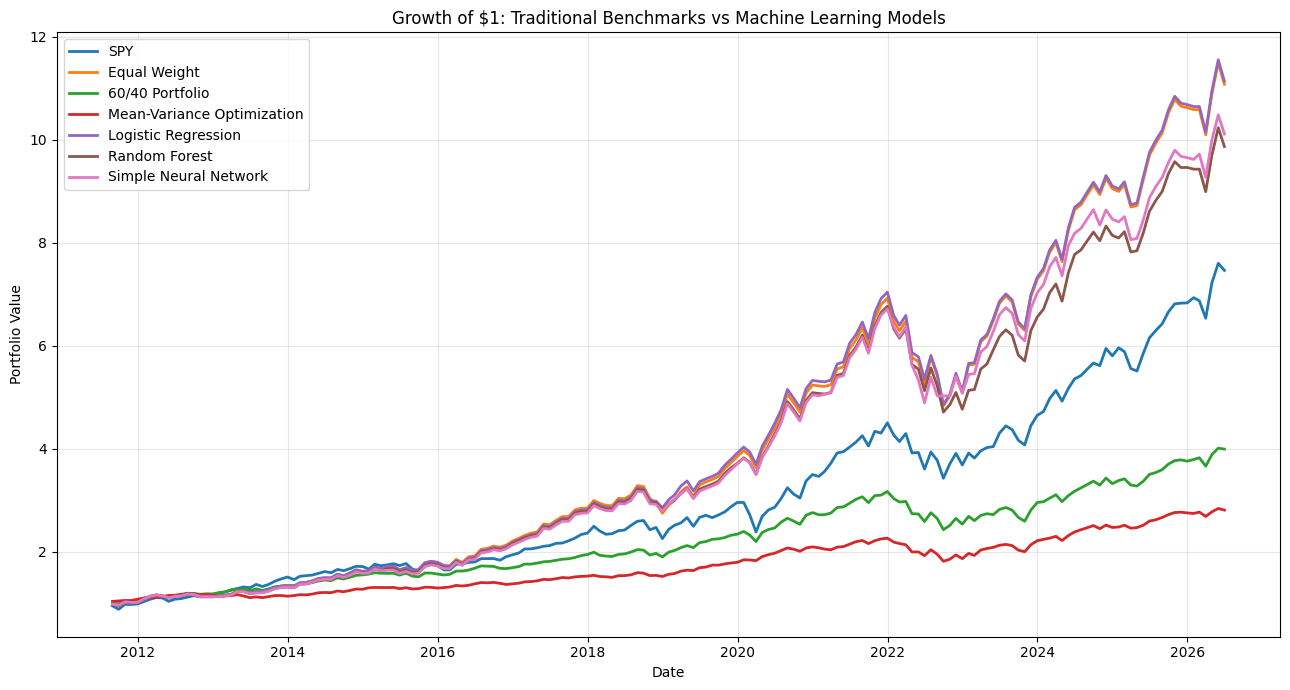

Stage 14A completed successfully.


In [32]:
# ============================================================
# STAGE 14A: GROWTH OF $1
# ============================================================

growth_of_one = (
    1 + comparison_returns
).cumprod()

plt.figure(figsize=(13, 7))

for strategy in growth_of_one.columns:
    plt.plot(
        growth_of_one.index,
        growth_of_one[strategy],
        label=strategy,
        linewidth=2
    )

plt.title(
    "Growth of $1: Traditional Benchmarks vs Machine Learning Models"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Stage 14A completed successfully.")

In [34]:
# ============================================================
# FIX: CREATE FINAL VALUES
# ============================================================

growth_of_one = (
    1 + comparison_returns
).cumprod()

final_values = (
    growth_of_one.iloc[-1]
    .sort_values(ascending=False)
    .to_frame("Final Value of $1")
)

display(
    final_values.style.format({
        "Final Value of $1": "${:.2f}"
    })
)

print("final_values created successfully.")

,Final Value of $1
Logistic Regression,$11.14
Equal Weight,$11.07
Simple Neural Network,$10.11
Random Forest,$9.86
SPY,$7.46
60/40 Portfolio,$3.99
Mean-Variance Optimization,$2.80


final_values created successfully.


In [35]:
# ============================================================
# STAGE 15: SAVE ALL RESULTS
# ============================================================

RESULT_FOLDER = "three_model_final_results"

os.makedirs(
    RESULT_FOLDER,
    exist_ok=True
)

# 1. Walk-forward probabilities and final predictions
walk_forward_results.to_csv(
    f"{RESULT_FOLDER}/walk_forward_predictions.csv"
)

# 2. Threshold sensitivity results
threshold_comparison.to_csv(
    f"{RESULT_FOLDER}/threshold_sensitivity.csv",
    index=False
)

# 3. Final classification comparison
if "classification_comparison" in globals():
    classification_comparison.to_csv(
        f"{RESULT_FOLDER}/classification_comparison.csv",
        index=False
    )

# 4. Final ML portfolios
logistic_portfolio.to_csv(
    f"{RESULT_FOLDER}/logistic_regression_portfolio.csv"
)

rf_portfolio.to_csv(
    f"{RESULT_FOLDER}/random_forest_portfolio.csv"
)

snn_portfolio.to_csv(
    f"{RESULT_FOLDER}/simple_neural_network_portfolio.csv"
)

# 5. Final asset selection summary
final_asset_selection_summary.to_csv(
    f"{RESULT_FOLDER}/asset_selection_summary.csv",
    index=False
)

# 6. MVO portfolio and weights
mvo_portfolio.to_csv(
    f"{RESULT_FOLDER}/mvo_portfolio.csv"
)

mvo_weights.to_csv(
    f"{RESULT_FOLDER}/mvo_weights.csv"
)

# 7. Monthly returns for all strategies
comparison_returns.to_csv(
    f"{RESULT_FOLDER}/strategy_monthly_returns.csv"
)

# 8. Performance comparison
performance_table.to_csv(
    f"{RESULT_FOLDER}/performance_comparison.csv",
    index=False
)

# 9. Growth of $1
growth_of_one.to_csv(
    f"{RESULT_FOLDER}/growth_of_one.csv"
)

# 10. Final values
final_values.to_csv(
    f"{RESULT_FOLDER}/final_value_of_one_dollar.csv"
)

# 11. Final thresholds
final_threshold_table = pd.DataFrame({
    "Model": list(FINAL_THRESHOLDS.keys()),
    "Final Threshold": list(FINAL_THRESHOLDS.values())
})

final_threshold_table.to_csv(
    f"{RESULT_FOLDER}/final_thresholds.csv",
    index=False
)

print("Stage 15 completed successfully.")
print("All results saved in:", RESULT_FOLDER)

print("\nSaved files:")

for filename in sorted(
    os.listdir(RESULT_FOLDER)
):
    print("-", filename)

Stage 15 completed successfully.
All results saved in: three_model_final_results

Saved files:
- asset_selection_summary.csv
- classification_comparison.csv
- final_thresholds.csv
- final_value_of_one_dollar.csv
- growth_of_one.csv
- logistic_regression_portfolio.csv
- mvo_portfolio.csv
- mvo_weights.csv
- performance_comparison.csv
- random_forest_portfolio.csv
- simple_neural_network_portfolio.csv
- strategy_monthly_returns.csv
- threshold_sensitivity.csv
- walk_forward_predictions.csv


In [36]:
# ============================================================
# STAGE 15B: ZIP RESULTS FOLDER
# ============================================================

import shutil

zip_path = shutil.make_archive(
    RESULT_FOLDER,
    "zip",
    RESULT_FOLDER
)

print("ZIP file created:")
print(zip_path)

ZIP file created:
/content/three_model_final_results.zip


In [37]:
from google.colab import files

files.download(
    f"{RESULT_FOLDER}.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>